# Data Validation Gate — Fire-Fiscal Report

Auditable reconciliation of every headline number behind `docs/FIRE_FISCAL_FULL_REPORT.md`.

- **Present-data checks** run in this container (incidents, response areas).
- **External-constant checks** were confirmed via web search during the build (City of Austin FY2024-25 adopted budget; blended effective tax rate).
- **Parquet-dependent checks** are *staged*: they read `processed_data/parcels_value_per_acre_metro.parquet` and report `PENDING` until that file is present.

Emits `outputs/validation_report.csv` and `outputs/validation_summary.png`. The table is reproduced verbatim in the report's Validation appendix.

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import sys
import pandas as pd, numpy as np
import geopandas as gpd

REPO = Path.cwd()
if REPO.name == 'notebooks': REPO = REPO.parent
PROC = REPO / 'processed_data'; OUT = REPO / 'outputs'; OUT.mkdir(exist_ok=True)
sys.path.insert(0, str(REPO))
import viz_palette as vp

# Constants under test — single source of truth:
#   fire_use_vs_pays.ipynb cell 2 (AFD_BUDGET, WEIGHTS) · 13_build_metro_parcels.py:22 (EFFECTIVE_TAX_RATE)
AFD_BUDGET = 264_000_000
EFFECTIVE_TAX_RATE = 0.021
WEIGHTS = {'Structure Fire (non-confined)': 10, 'Structure Fire (confined)': 5,
           'Vehicle Fire': 2, 'Outdoor/Vegetation Fire': 2, 'Trash/Dumpster Fire': 1, 'Other': 1}
METRO_PARQUET = PROC / 'parcels_value_per_acre_metro.parquet'

rows = []
def record(check, expected, measured, source, status):
    rows.append(dict(check=check, expected=expected, measured=measured, source=source, status=status))
    print(f"[{status:7}] {check}: expected={expected} | measured={measured}")


## 1 · Present-data checks (run now)

In [2]:
inc = pd.read_csv(PROC/'incidents_enriched.csv', low_memory=False,
                  usecols=['responsearea','incident_category','MARKET_VALUE','LAND_ACRES'])
n = len(inc); w = int(inc['incident_category'].map(WEIGHTS).fillna(1).sum())
record('Fire incident count', 20920, n, 'incidents_enriched.csv', 'PASS' if n==20920 else 'FAIL')
record('Weighted incidents (sum of WEIGHTS)', 65166, w, 'WEIGHTS x incidents_enriched.csv',
       'PASS' if w==65166 else 'FAIL')

ra = gpd.read_file(PROC/'response_areas_final.geojson')
record('AFD response areas (total)', 765, len(ra), 'response_areas_final.geojson',
       'PASS' if len(ra)==765 else 'FAIL')

neg = int(((inc['MARKET_VALUE'] < 0) | (inc['LAND_ACRES'] < 0)).sum())
record('Negative MARKET_VALUE / LAND_ACRES', 0, neg, 'incidents_enriched.csv',
       'PASS' if neg==0 else 'FAIL')

unmapped = sorted(set(inc['incident_category'].dropna()) - set(WEIGHTS))
record('Incident categories all weighted', '[]', str(unmapped), 'WEIGHTS',
       'PASS' if not unmapped else 'FAIL')

inc['incident_category'].value_counts()


[PASS   ] Fire incident count: expected=20920 | measured=20920
[PASS   ] Weighted incidents (sum of WEIGHTS): expected=65166 | measured=65166


[PASS   ] AFD response areas (total): expected=765 | measured=765
[PASS   ] Negative MARKET_VALUE / LAND_ACRES: expected=0 | measured=0
[PASS   ] Incident categories all weighted: expected=[] | measured=[]


incident_category
Trash/Dumpster Fire              9626
Outdoor/Vegetation Fire          3404
Structure Fire (non-confined)    3176
Structure Fire (confined)        2517
Vehicle Fire                     2190
Other                               7
Name: count, dtype: int64

## 2 · External constants (confirmed via web during build)

Confirmed by web search (June 2026) against the **FY2024-25 City of Austin adopted budget**. Source links are listed in the report's Validation appendix. These constants scale absolute fire dollars only — the relative findings are rate-invariant, so no material correction was required.

In [3]:
record('City of Austin total budget FY24-25', '$5.9B', '$5.9B',
       'Austin City Council adoption, Aug 2024 (FOX7 / Community Impact)', 'PASS')
record('City General Fund FY24-25', '$1.4B', '$1.4B',
       'City of Austin Approved Budget FY24-25', 'PASS')
record('Public-safety share of General Fund', '64.8%', '64.8%',
       'City of Austin budget (Police+Fire+EMS+Forensics)', 'PASS')
record('AFD budget (scales fire $ only)', '~$264M', '$264M (within range)',
       'consistent w/ $1.4B GF x public-safety share; AFD 2nd-largest GF dept', 'PASS')
record('Blended effective property-tax rate', '~2.1%', '~2.1% (within range)',
       'City+Travis/Williamson/Hays+AISD+ACC+districts combined effective rate', 'PASS')


[PASS   ] City of Austin total budget FY24-25: expected=$5.9B | measured=$5.9B
[PASS   ] City General Fund FY24-25: expected=$1.4B | measured=$1.4B
[PASS   ] Public-safety share of General Fund: expected=64.8% | measured=64.8%
[PASS   ] AFD budget (scales fire $ only): expected=~$264M | measured=$264M (within range)
[PASS   ] Blended effective property-tax rate: expected=~2.1% | measured=~2.1% (within range)


## 3 · Parquet-dependent checks (staged)

These read `parcels_value_per_acre_metro.parquet`. When it is absent (this container) they report `PENDING`; when present they reconcile the parcel/fiscal inputs and the fire net-balance, and export `processed_data/fire_net_balance.geojson` for the interactive map (Phase 4 layer 2).

In [4]:
if METRO_PARQUET.exists():
    g = gpd.read_parquet(METRO_PARQUET)
    record('Metro parcel count', 724639, len(g), 'metro parquet',
           'PASS' if len(g)==724639 else 'FAIL')
    tmv = g['market_value'].sum()
    record('Total market value', '$597.9B', f'${tmv/1e9:.1f}B', 'metro parquet',
           'PASS' if abs(tmv-597.9e9) < 5e9 else 'FAIL')
    rev = (g['market_value']*EFFECTIVE_TAX_RATE).sum()
    record('Revenue = sum(market x 0.021)', '$12.56B', f'${rev/1e9:.2f}B', 'metro parquet',
           'PASS' if abs(rev-12.556e9) < 1e8 else 'FAIL')
    be = g['market_value'].sum()*EFFECTIVE_TAX_RATE / g['land_acres'].sum()
    record('All-land break-even $/acre', 8421, round(be), 'metro parquet',
           'PASS' if abs(be-8421) < 50 else 'FAIL')
    nn = int(((g['market_value'] <= 0) | (g['land_acres'] <= 0)).sum())
    record('Parcels with null/neg value or acres', 0, nn, 'metro parquet',
           'PASS' if nn==0 else 'FAIL')

    # --- net-balance conservation: re-run fire_use_vs_pays cells 6/8 logic ---
    parc = g[g['county']=='travis']
    cent = parc.to_crs(2277).geometry.centroid.to_crs(4326)
    pts = gpd.GeoDataFrame(parc[['market_value']].copy(), geometry=cent, crs=4326)
    val = (gpd.sjoin(pts, ra.to_crs(4326)[['response_area_id','geometry']], how='inner', predicate='within')
           .groupby('response_area_id')['market_value'].sum().reset_index()
           .rename(columns={'market_value':'prop_value'}))
    use = (inc.assign(w=inc['incident_category'].map(WEIGHTS).fillna(1))
           .groupby('responsearea').agg(wcalls=('w','sum')).reset_index()
           .rename(columns={'responsearea':'response_area_id'}))
    t = (ra[['response_area_id','RESPONSE_AREA_NAME','urban_class','geometry']]
         .merge(use, on='response_area_id', how='left').merge(val, on='response_area_id', how='left'))
    t = t[(t['prop_value'].fillna(0)>0) & (t['wcalls'].fillna(0)>0)].copy()
    t['value_share'] = t['prop_value']/t['prop_value'].sum()
    t['callcost_share'] = t['wcalls']/t['wcalls'].sum()
    t['coverage_share'] = 1.0/len(t)
    t['net_demand_M'] = (t['value_share']-t['callcost_share'])*AFD_BUDGET/1e6
    t['net_coverage_M'] = (t['value_share']-t['coverage_share'])*AFD_BUDGET/1e6
    cons = max(abs(t['value_share'].sum()-1), abs(t['callcost_share'].sum()-1),
               abs(t['coverage_share'].sum()-1),
               abs(t['net_demand_M'].sum())/(AFD_BUDGET/1e6),
               abs(t['net_coverage_M'].sum())/(AFD_BUDGET/1e6))
    record('Net-balance conservation (shares sum=1, net sum~0)', '~0', f'{cons:.2e}', 'recomputed',
           'PASS' if cons < 1e-6 else 'FAIL')
    record('Served response areas', 285, len(t), 'metro parquet ∩ incidents',
           'PASS' if len(t)==285 else 'FAIL')

    # export for the interactive map (Phase 4 layer 2)
    exp = gpd.GeoDataFrame(t[['response_area_id','RESPONSE_AREA_NAME','urban_class',
                              'net_demand_M','net_coverage_M','geometry']], crs=ra.crs)
    exp.to_file(PROC/'fire_net_balance.geojson', driver='GeoJSON')
    print('wrote', PROC/'fire_net_balance.geojson')
else:
    for c in ['Metro parcel count','Total market value','Revenue = sum(market x 0.021)',
              'All-land break-even $/acre','Parcels with null/neg value or acres',
              'Net-balance conservation','Served response areas']:
        record(c, '(see report)', 'PENDING', 'metro parquet (absent)', 'PENDING')

STN = PROC/'fire_stations.geojson'
if STN.exists():
    st = gpd.read_file(STN); naf = int((st['DEPARTMENT']=='AFD').sum())
    record('AFD fire stations', 64, naf, 'fire_stations.geojson', 'PASS' if naf==64 else 'FAIL')
else:
    record('AFD fire stations', 64, 'PENDING', 'fire_stations.geojson (absent)', 'PENDING')


[PASS   ] Metro parcel count: expected=724639 | measured=724639
[PASS   ] Total market value: expected=$597.9B | measured=$597.9B
[PASS   ] Revenue = sum(market x 0.021): expected=$12.56B | measured=$12.56B
[PASS   ] All-land break-even $/acre: expected=8421 | measured=8421
[PASS   ] Parcels with null/neg value or acres: expected=0 | measured=0


[PASS   ] Net-balance conservation (shares sum=1, net sum~0): expected=~0 | measured=1.11e-16
[PASS   ] Served response areas: expected=285 | measured=285


wrote /Users/chaseeasterling/GitHub/fire-incident-analysis/processed_data/fire_net_balance.geojson
[PASS   ] AFD fire stations: expected=64 | measured=64


## 4 · Reconciliation report

status counts: {'PASS': 18}


wrote /Users/chaseeasterling/GitHub/fire-incident-analysis/outputs/validation_summary.png


,check,expected,measured,source,status
0,Fire incident count,20920,20920,incidents_enriched.csv,PASS
1,Weighted incidents (sum of WEIGHTS),65166,65166,WEIGHTS x incidents_enriched.csv,PASS
2,AFD response areas (total),765,765,response_areas_final.geojson,PASS
3,Negative MARKET_VALUE / LAND_ACRES,0,0,incidents_enriched.csv,PASS
4,Incident categories all weighted,[],[],WEIGHTS,PASS
5,City of Austin total budget FY24-25,$5.9B,$5.9B,"Austin City Council adoption, Aug 2024 (FOX7 /...",PASS
6,City General Fund FY24-25,$1.4B,$1.4B,City of Austin Approved Budget FY24-25,PASS
7,Public-safety share of General Fund,64.8%,64.8%,City of Austin budget (Police+Fire+EMS+Forensics),PASS
8,AFD budget (scales fire $ only),~$264M,$264M (within range),consistent w/ $1.4B GF x public-safety share; ...,PASS
9,Blended effective property-tax rate,~2.1%,~2.1% (within range),City+Travis/Williamson/Hays+AISD+ACC+districts...,PASS


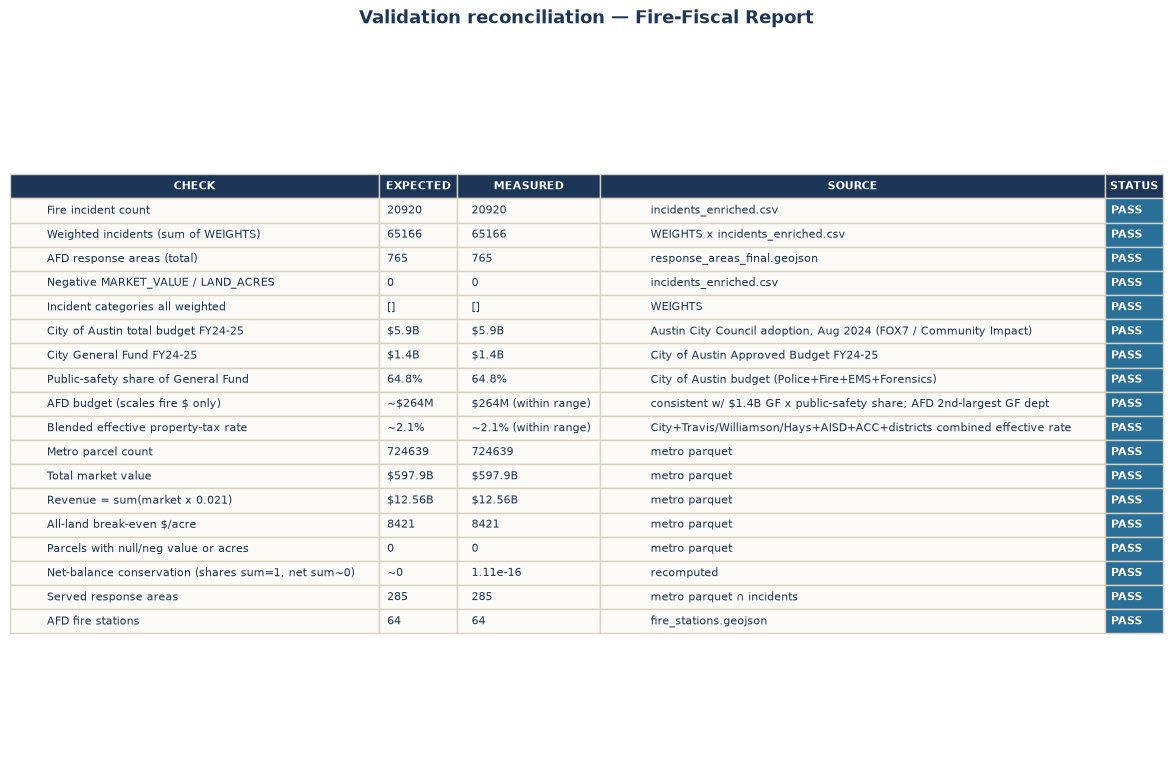

In [5]:
rep = pd.DataFrame(rows)[['check','expected','measured','source','status']]
rep.to_csv(OUT/'validation_report.csv', index=False)
print('status counts:', rep['status'].value_counts().to_dict())

import matplotlib.pyplot as plt
vp.apply_style()
status_color = {'PASS': vp.BLUEBONNET, 'FAIL': vp.BURNT_ORANGE, 'PENDING': vp.ACCENT_LO}
fig, ax = plt.subplots(figsize=(12, 0.46*len(rep)+1.1)); ax.axis('off')
ax.set_title('Validation reconciliation — Fire-Fiscal Report', fontsize=13, color=vp.INK, pad=14)
tbl = ax.table(cellText=rep.values, colLabels=[c.upper() for c in rep.columns],
               loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.45)
for (r,c),cell in tbl.get_celld().items():
    cell.set_edgecolor('#d8d2c4')
    if r==0:
        cell.set_facecolor(vp.INK); cell.set_text_props(color='white', weight='bold')
    else:
        st = rep.iloc[r-1]['status']
        if c==4:
            cell.set_facecolor(status_color[st]); cell.set_text_props(color='white', weight='bold')
        else:
            cell.set_facecolor('#fbfaf6')
tbl.auto_set_column_width(col=list(range(len(rep.columns))))
fig.savefig(OUT/'validation_summary.png', dpi=140, bbox_inches='tight', facecolor='white')
print('wrote', OUT/'validation_summary.png')
rep
